# DAV Threshold Interactive Analysis

This notebook lets you interactively analyze **Daily Amplitude Variation (DAV)** thresholds
for any cube, year, and location, without needing to run the full HPC pipeline.

### This code is created to be used for the supercomputer, but it can be modified for any other machine. It works based on the cubes produced by Molly.

---

##  How to use this notebook

1. **Section 1** : Set up imports (run once)
2. **Section 2** : Configure your cube, years, and location (edit values here)
3. **Section 3** : Load cube data and find your pixel
4. **Section 4A** : Single-year DAV analysis (one year)
5. **Section 4B** : Cumulative DAV analysis (all years pooled)
6. **Section 4C** : Region of Interest (ROI) analysis
7. **Section 4D** : Convert ROI CSV to GeoTIFF
8. **Section 5** : Save single-pixel results to CSV
9. **Section 6** : Single-Pixel Results Summary

---
>  **Run cells in order top to bottom.** Each section depends on the previous one.

## Required files

**Custom scripts (must be in same directory as this notebook):**
1. `CETB_IO.py` >> provides `read_Tb_whole`, `years_for`, `find_cube_offset`
2. `CETB_algorithmsMB_Final.py` >> provides `calc_DAV`

**Required data files:**
3. `SnowClass_Global_1km.nc` >> global snow classification raster

**This notebook:**
4. `DAV_Interactive_Analysis.ipynb`

## 1. Imports
Run these cells once at the start of every session.

In [12]:
import os

# --- Fix PROJ_LIB for cetb environment (must run before any geo imports) ---
os.environ["PROJ_LIB"]  = "/projects/mabo7890/software/anaconda/envs/cetb/share/proj"
os.environ["GDAL_DATA"] = "/projects/mabo7890/software/anaconda/envs/cetb/share/gdal"

print("PROJ_LIB set to:", os.environ["PROJ_LIB"])

PROJ_LIB set to: /projects/mabo7890/software/anaconda/envs/cetb/share/proj


In [13]:
import os
import csv
import glob
import logging
from datetime import datetime

import numpy as np
import pandas as pd
import rasterio
import xarray as xr
import matplotlib.pyplot as plt
from rasterio.transform import Affine
from pyproj import Transformer

# Set up logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
log = logging.getLogger(__name__)

# ---- Paths ----
os.chdir("/projects/mabo7890/Melt_Codes/scripts")

from CETB_IO import read_Tb_whole, years_for, find_cube_offset
from CETB_algorithmsMB_Final import calc_DAV

# ---- Transformers ----
to_ease   = Transformer.from_crs("EPSG:4326", "EPSG:6931", always_xy=True)
to_latlon = Transformer.from_crs("EPSG:6931", "EPSG:4326", always_xy=True)

# ---- Snow class categories ----
categories = {
    1: "Tundra",
    2: "Boreal Forest",
    3: "Maritime",
    4: "Ephemeral",
    5: "Prairie",
    6: "Montane Forest",
    7: "Ice",
    8: "Ocean",
}

# Snow classes that get blank thresholds (same as HPC script)
BLANK_SNOW_CLASSES = {"Ocean", "Maritime"}

# ---- DAV helper ----
def cal_date_to_doy(cal_date_array):
    """Convert cal_date array to day-of-year (1-366)."""
    cal_date_arr = np.asarray(cal_date_array)
    doy = np.zeros(len(cal_date_arr), dtype=np.int32)
    for i, d in enumerate(cal_date_arr):
        try:
            ts = pd.Timestamp(d)
            doy[i] = ts.day_of_year
        except Exception:
            try:
                dt = datetime.strptime(str(int(d)), "%Y%m%d")
                doy[i] = dt.timetuple().tm_yday
            except Exception:
                doy[i] = -1
    return doy

print(" Imports successful — ready to go!")

 Imports successful — ready to go!


## 2. Configuration >> Edit This Cell

This is the only cell you need to edit. Set your cube, years, and location here.

| Parameter | What it means |
|-----------|---------------|
| `region` | Cube folder name, e.g. `"N25_44"` |
| `sat_SIR` | Satellite: `"F13"` (SSMI 1995-2009) or `"F16"` (SSMIS 2005-2019) |
| `sensor_SIR` | Sensor: `"SSMI"` or `"SSMIS"` |
| `year_single` | The single year for Section 4A analysis |
| `year_list` | All years for Section 4B cumulative analysis |
| `pixel_lat_input` | Latitude of the pixel to analyze (°N) |
| `pixel_lon_input` | Longitude of the pixel to analyze (°E, negative = West) |
| `MELT_DOY_START` | Start day-of-year for melt season window |
| `MELT_DOY_END` | End day-of-year for melt season window |

In [15]:
# ============================================================
#  EDIT THESE VALUES
# ============================================================

# --- Cube to analyze ---
region    = "N25_44"   # e.g. N25_44, N25_43, N25_d34 ...
SiteLabel = "Cube44"   # used in output filenames

# --- Satellite / Sensor ---
sat_SIR     = "F13"    # F13 = SSMI (1995-2009) | F16 = SSMIS (2005-2019)
sensor_SIR  = "SSMI"   # SSMI or SSMIS
channel_SIR = "37V"
alg_SIR     = "SIR"
hemName     = "N"

# --- Single year for Section 4A ---
year_single = 2003    #  change to any year in your record

# --- All years for Section 4B cumulative analysis ---
all_years  = years_for(sat_SIR)
year_list  = list(all_years[0:15])     #  change [0:15] to [0:] for ALL years

# --- Pixel location (lat/lon) ---
pixel_lat_input = 60.5    #  latitude  (°N)
pixel_lon_input = -135.0  #  longitude (°E, negative = West)

# --- Melt season DOY window (used in cumulative analysis) ---
# DOY 60 = ~March 1,  DOY 180 = ~June 29
MELT_DOY_START = 60    #  start of melt season
MELT_DOY_END   = 180   #  end of melt season

# --- Output directory ---
OutDir = "/scratch/alpine/mabo7890/DAV_Thresholds/Interactive"
os.makedirs(OutDir, exist_ok=True)

# --- Paths (auto-built, do not edit) ---
dataDir     = "/pl/active/PMESDR/CETB_cubesv2"
if sensor_SIR in ["SSMI", "SSMIS"]:
    provider = "L1C"
    version  = "v2.*"

datadir_SIR    = f"{dataDir}/{sat_SIR}_{sensor_SIR}/{hemName}/nc_cubes/cubes_{region}/"
prefix_SIR     = f"CETB.cubefile.{region}.{sat_SIR}_{sensor_SIR}-{channel_SIR}-{alg_SIR}-{provider}-{version}"
snowclass_path = "/projects/mabo7890/Melt_Codes/SnowClass_Global_1km.nc"

# ============================================================
print(f" Cube        : {region}  ({SiteLabel})")
print(f" Satellite   : {sat_SIR} / {sensor_SIR}")
print(f" Single year : {year_single}")
print(f" Year list   : {year_list[0]} → {year_list[-1]}  ({len(year_list)} years)")
print(f" Location    : Lat={pixel_lat_input}°N  Lon={pixel_lon_input}°E")
print(f" Melt season : DOY {MELT_DOY_START} → {MELT_DOY_END}")
print(f" Output dir  : {OutDir}")

 Cube        : N25_44  (Cube44)
 Satellite   : F13 / SSMI
 Single year : 2003
 Year list   : 1995 → 2009  (15 years)
 Location    : Lat=60.5°N  Lon=-135.0°E
 Melt season : DOY 60 → 180
 Output dir  : /scratch/alpine/mabo7890/DAV_Thresholds/Interactive


## 3. Load Cube Data

Reads the TB data for the cube and computes DAV.
Finds the nearest pixel to your requested lat/lon.

> Loading TB may take a minute. DAV is computed from the TB time series.

In [16]:
# --- Get cube spatial extent ---
find_cube_offset(region, cubeDir=datadir_SIR, cubeType=f"{channel_SIR}-{alg_SIR}", verbose=False)

sir_files = sorted(glob.glob(os.path.join(datadir_SIR, f"{prefix_SIR}*.nc")))
if not sir_files:
    raise FileNotFoundError(f"No .nc files found in {datadir_SIR}")

print(f"Found {len(sir_files)} .nc files in cube directory")

ds = xr.open_dataset(sir_files[0])
ny, nx = ds.sizes["y"], ds.sizes["x"]
lat2d  = ds["latitude"].values
lon2d  = ds["longitude"].values
ds.close()

print(f"\n Cube grid size : {ny} rows x {nx} cols = {ny*nx:,} pixels")
print(f" Lat range      : {lat2d.min():.2f}°N → {lat2d.max():.2f}°N")
print(f" Lon range      : {lon2d.min():.2f}°E → {lon2d.max():.2f}°E")

# --- Find nearest pixel to requested lat/lon ---
dist = np.sqrt((lat2d - pixel_lat_input)**2 + (lon2d - pixel_lon_input)**2)
pixel_row, pixel_col = np.unravel_index(np.argmin(dist), dist.shape)

pixel_lat = lat2d[pixel_row, pixel_col]
pixel_lon = lon2d[pixel_row, pixel_col]

print(f"\n Requested      : Lat={pixel_lat_input}°N  Lon={pixel_lon_input}°E")
print(f" Nearest pixel  : row={pixel_row}, col={pixel_col}")
print(f"   Actual Lat={pixel_lat:.4f}°N   Lon={pixel_lon:.4f}°E")
print(f"   Distance to requested point: {dist[pixel_row, pixel_col]:.4f}°")

if dist[pixel_row, pixel_col] > 1.0:
    print(f"  WARNING: Nearest pixel is more than 1° away — check lat/lon bounds.")

# --- Load snow class for this pixel ---
ds_snow    = xr.open_dataset(snowclass_path)
snow_val   = ds_snow["SnowClass"].sel(
    lat=pixel_lat, lon=pixel_lon, method="nearest"
).values
ds_snow.close()
snow_class = categories.get(int(snow_val), "Unknown")
print(f"   Snow Class = {snow_class} (code={int(snow_val)})")

# --- Load TB data for small window around pixel (memory efficient) ---
row_margin = 2
col_margin = 2
r0 = max(0,  pixel_row - row_margin)
r1 = min(ny, pixel_row + row_margin + 1)
c0 = max(0,  pixel_col - col_margin)
c1 = min(nx, pixel_col + col_margin + 1)

print(f"\n Loading TB data for years {year_list[0]}-{year_list[-1]}...")
print(f"   Spatial subset: rows {r0}:{r1}, cols {c0}:{c1} (5x5 window)")

data_SIR  = read_Tb_whole(
    datadir_SIR, prefix_SIR, year_list,
    r0, r1, c0, c1,
)
TB        = np.asarray(data_SIR["TB"])        # (time, 5, 5)
cal_date  = data_SIR["cal_date"]
cal_year  = np.asarray(data_SIR["cal_year"])
cal_month = data_SIR["cal_month"]

print(f" TB loaded: {TB.shape[0]} time steps")

# --- Compute DAV from TB ---
print(f" Computing DAV...")
DAV = np.asarray(calc_DAV(TB))  # (time, 5, 5)
print(f" DAV computed: shape={DAV.shape}")

# --- Compute DOY array ---
doy = cal_date_to_doy(cal_date)
melt_mask = (doy >= MELT_DOY_START) & (doy <= MELT_DOY_END)
print(f"   Melt season time steps (DOY {MELT_DOY_START}-{MELT_DOY_END}): {melt_mask.sum():,} / {len(doy):,}")

# --- Extract pixel time series ---
pixel_row_local = pixel_row - r0
pixel_col_local = pixel_col - c0

tb_series  = TB[:, pixel_row_local, pixel_col_local]
dav_series = DAV[:, pixel_row_local, pixel_col_local]

print(f"\n TB  time series : valid={( ~np.isnan(tb_series)).sum():,}  "
      f"range=[{np.nanmin(tb_series):.2f}, {np.nanmax(tb_series):.2f}] K")
print(f" DAV time series : valid={(~np.isnan(dav_series)).sum():,}  "
      f"range=[{np.nanmin(dav_series):.2f}, {np.nanmax(dav_series):.2f}] K")

Reading offset information from cubeFile=/pl/active/PMESDR/CETB_cubesv2/F13_SSMI/N/nc_cubes/cubes_N25_44/CETB.cubefile.N25_44.F13_SSMI-37V-SIR-L1C-v2.0.2008.TB.nc...
Found 60 .nc files in cube directory

 Cube grid size : 640 rows x 640 cols = 409,600 pixels
 Lat range      : 51.25°N → 77.29°N
 Lon range      : -161.53°E → -108.47°E

 Requested      : Lat=60.5°N  Lon=-135.0°E
 Nearest pixel  : row=223, col=223
   Actual Lat=60.5100°N   Lon=-135.0000°E
   Distance to requested point: 0.0100°
   Snow Class = Boreal Forest (code=2)

 Loading TB data for years 1995-2009...
   Spatial subset: rows 221:226, cols 221:226 (5x5 window)
Next filename=/pl/active/PMESDR/CETB_cubesv2/F13_SSMI/N/nc_cubes/cubes_N25_44/CETB.cubefile.N25_44.F13_SSMI-37V-SIR-L1C-v2.0.1995.TB.nc...
Next filename=/pl/active/PMESDR/CETB_cubesv2/F13_SSMI/N/nc_cubes/cubes_N25_44/CETB.cubefile.N25_44.F13_SSMI-37V-SIR-L1C-v2.0.1996.TB.nc...
Next filename=/pl/active/PMESDR/CETB_cubesv2/F13_SSMI/N/nc_cubes/cubes_N25_44/CETB.cube

## 4A. Single-Year DAV Analysis

Compute DAV thresholds (p90, p95, average) for **one specific year**.

>  Change `year_single` in Section 2, then re-run this cell.

  Single-Year DAV Analysis: 2003
  Pixel: Lat=60.5100°N  Lon=-135.0000°E
  (row=223, col=223)
  Snow class: Boreal Forest
   Time steps for 2003: 730

 DAV Results for year 2003:
   Location          : Lat=60.5100°N  Lon=-135.0000°E
   Valid DAV obs     : 712
   DAV p90 Threshold : 9.37 K
   DAV p95 Threshold : 13.53 K
   DAV Average       : 11.45 K


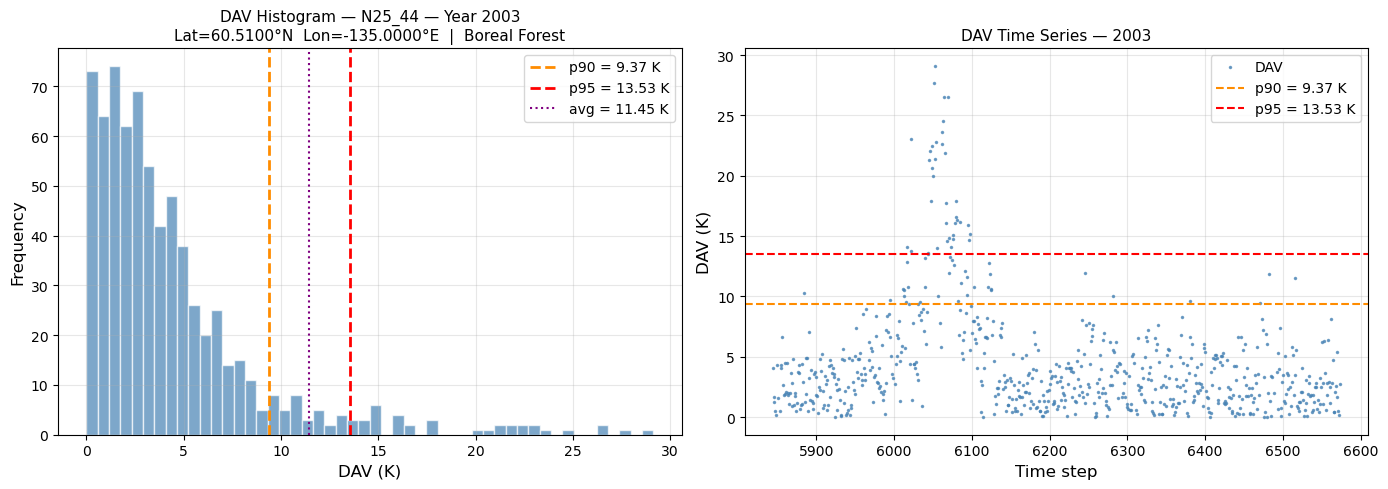


 Plot saved to /scratch/alpine/mabo7890/DAV_Thresholds/Interactive


In [17]:
print(f"=" * 55)
print(f"  Single-Year DAV Analysis: {year_single}")
print(f"  Pixel: Lat={pixel_lat:.4f}°N  Lon={pixel_lon:.4f}°E")
print(f"  (row={pixel_row}, col={pixel_col})")
print(f"  Snow class: {snow_class}")
print(f"=" * 55)

if year_single not in year_list:
    raise ValueError(f"year_single={year_single} is not in year_list. "
                     "Add it to year_list in Section 2.")

# Mask for this year
year_mask_single = (cal_year == year_single)

if not np.any(year_mask_single):
    raise ValueError(f"No time steps found for year {year_single}.")

print(f"   Time steps for {year_single}: {year_mask_single.sum()}")

# DAV values for this year
dav_single = dav_series[year_mask_single]
dav_valid  = dav_single[~np.isnan(dav_single)]

if len(dav_valid) == 0:
    print("  No valid DAV values for this year.")
    p90_single = p95_single = avg_single = None
else:
    p90_single = float(np.nanquantile(dav_valid, 0.90))
    p95_single = float(np.nanquantile(dav_valid, 0.95))
    avg_single = (p90_single + p95_single) / 2.0

    print(f"\n DAV Results for year {year_single}:")
    print(f"   Location          : Lat={pixel_lat:.4f}°N  Lon={pixel_lon:.4f}°E")
    print(f"   Valid DAV obs     : {len(dav_valid):,}")
    print(f"   DAV p90 Threshold : {p90_single:.2f} K")
    print(f"   DAV p95 Threshold : {p95_single:.2f} K")
    print(f"   DAV Average       : {avg_single:.2f} K")

    # --- Plot ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: DAV histogram
    ax = axes[0]
    ax.hist(dav_valid, bins=50, color="steelblue", alpha=0.7, edgecolor="white")
    ax.axvline(p90_single, color="darkorange", linewidth=2, linestyle="--",
               label=f"p90 = {p90_single:.2f} K")
    ax.axvline(p95_single, color="red", linewidth=2, linestyle="--",
               label=f"p95 = {p95_single:.2f} K")
    ax.axvline(avg_single, color="purple", linewidth=1.5, linestyle=":",
               label=f"avg = {avg_single:.2f} K")
    ax.set_xlabel("DAV (K)", fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12)
    ax.set_title(
        f"DAV Histogram — {region} — Year {year_single}\n"
        f"Lat={pixel_lat:.4f}°N  Lon={pixel_lon:.4f}°E  |  {snow_class}",
        fontsize=11
    )
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # Right: DAV time series for this year
    ax2 = axes[1]
    t_single = np.where(year_mask_single)[0]
    ax2.plot(t_single, dav_series[year_mask_single], ".", markersize=3,
             color="steelblue", alpha=0.7, label="DAV")
    ax2.axhline(p90_single, color="darkorange", linewidth=1.5, linestyle="--",
                label=f"p90 = {p90_single:.2f} K")
    ax2.axhline(p95_single, color="red", linewidth=1.5, linestyle="--",
                label=f"p95 = {p95_single:.2f} K")
    ax2.set_xlabel("Time step", fontsize=12)
    ax2.set_ylabel("DAV (K)", fontsize=12)
    ax2.set_title(f"DAV Time Series — {year_single}", fontsize=11)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    fig.savefig(
        os.path.join(OutDir, f"DAV_histogram_{region}_{year_single}_lat{pixel_lat:.2f}_lon{pixel_lon:.2f}.png"),
        dpi=150, bbox_inches="tight"
    )
    plt.show()
    print(f"\n Plot saved to {OutDir}")

## 4B.  Cumulative DAV Analysis >> All Years + Melt Season

Compute DAV thresholds pooling **all years** and filtering to the **melt season window**
(DOY `MELT_DOY_START` to `MELT_DOY_END`). This mirrors the HPC pipeline exactly.

> This gives a more stable threshold because it uses more observations.

  Cumulative DAV Analysis: 1995–2009
  Melt season: DOY 60–180
  Pixel: Lat=60.5100°N  Lon=-135.0000°E
  Snow class: Boreal Forest

   Total melt-season obs (all years) : 3,630
   Valid (non-NaN)                   : 3,097

 Cumulative DAV Results (1995–2009):
   Location          : Lat=60.5100°N  Lon=-135.0000°E
   DAV p90 Threshold : 18.64 K
   DAV p95 Threshold : 22.78 K
   DAV Average       : 20.71 K


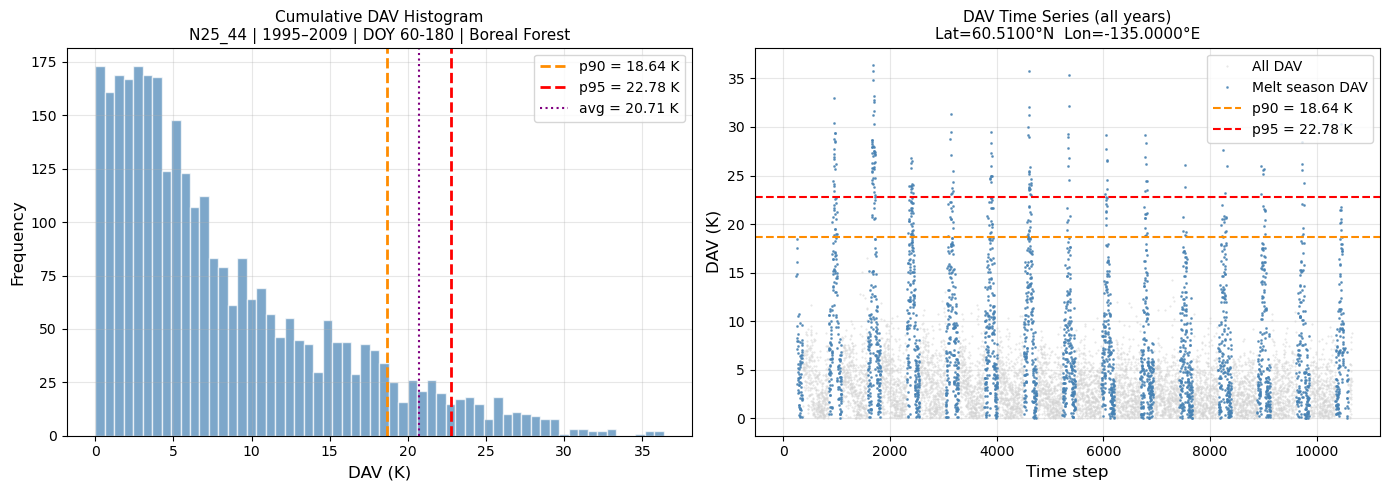


 Plot saved to /scratch/alpine/mabo7890/DAV_Thresholds/Interactive

  Comparison Summary
                            Single year      Cumulative
  Year(s)                          2003       1995-2009
  Location                    Lat=60.51      Lon=-135.0
  DAV p90 (K)                      9.37           18.64
  DAV p95 (K)                     13.53           22.78
  DAV Average (K)                 11.45           20.71


In [18]:
print(f"=" * 55)
print(f"  Cumulative DAV Analysis: {year_list[0]}–{year_list[-1]}")
print(f"  Melt season: DOY {MELT_DOY_START}–{MELT_DOY_END}")
print(f"  Pixel: Lat={pixel_lat:.4f}°N  Lon={pixel_lon:.4f}°E")
print(f"  Snow class: {snow_class}")
print(f"=" * 55)

# Pool all melt-season DAV values across all years
dav_pooled = dav_series[melt_mask]
dav_valid_all = dav_pooled[~np.isnan(dav_pooled)]

print(f"\n   Total melt-season obs (all years) : {len(dav_pooled):,}")
print(f"   Valid (non-NaN)                   : {len(dav_valid_all):,}")

if len(dav_valid_all) == 0:
    print("  No valid DAV values for this pixel in the melt season window.")
    p90_all = p95_all = avg_all = None
else:
    p90_all = float(np.nanquantile(dav_valid_all, 0.90))
    p95_all = float(np.nanquantile(dav_valid_all, 0.95))
    avg_all = (p90_all + p95_all) / 2.0

    print(f"\n Cumulative DAV Results ({year_list[0]}–{year_list[-1]}):")
    print(f"   Location          : Lat={pixel_lat:.4f}°N  Lon={pixel_lon:.4f}°E")
    print(f"   DAV p90 Threshold : {p90_all:.2f} K")
    print(f"   DAV p95 Threshold : {p95_all:.2f} K")
    print(f"   DAV Average       : {avg_all:.2f} K")

    # --- Plot ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: pooled DAV histogram
    ax = axes[0]
    ax.hist(dav_valid_all, bins=60, color="steelblue", alpha=0.7, edgecolor="white")
    ax.axvline(p90_all, color="darkorange", linewidth=2, linestyle="--",
               label=f"p90 = {p90_all:.2f} K")
    ax.axvline(p95_all, color="red", linewidth=2, linestyle="--",
               label=f"p95 = {p95_all:.2f} K")
    ax.axvline(avg_all, color="purple", linewidth=1.5, linestyle=":",
               label=f"avg = {avg_all:.2f} K")
    ax.set_xlabel("DAV (K)", fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12)
    ax.set_title(
        f"Cumulative DAV Histogram\n"
        f"{region} | {year_list[0]}–{year_list[-1]} | DOY {MELT_DOY_START}-{MELT_DOY_END} | {snow_class}",
        fontsize=11
    )
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # Right: full DAV time series with melt season highlighted
    ax2 = axes[1]
    ax2.plot(range(len(dav_series)), dav_series, ".", markersize=1,
             color="lightgray", alpha=0.6, label="All DAV")
    melt_idx = np.where(melt_mask)[0]
    ax2.plot(melt_idx, dav_series[melt_mask], ".", markersize=2,
             color="steelblue", alpha=0.7, label="Melt season DAV")
    ax2.axhline(p90_all, color="darkorange", linewidth=1.5, linestyle="--",
                label=f"p90 = {p90_all:.2f} K")
    ax2.axhline(p95_all, color="red", linewidth=1.5, linestyle="--",
                label=f"p95 = {p95_all:.2f} K")
    ax2.set_xlabel("Time step", fontsize=12)
    ax2.set_ylabel("DAV (K)", fontsize=12)
    ax2.set_title(
        f"DAV Time Series (all years)\n"
        f"Lat={pixel_lat:.4f}°N  Lon={pixel_lon:.4f}°E",
        fontsize=11
    )
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    fig.savefig(
        os.path.join(OutDir, f"DAV_cumulative_{region}_{year_list[0]}-{year_list[-1]}_lat{pixel_lat:.2f}_lon{pixel_lon:.2f}.png"),
        dpi=150, bbox_inches="tight"
    )
    plt.show()
    print(f"\n Plot saved to {OutDir}")

# --- Comparison summary ---
print(f"\n{'='*55}")
print(f"  Comparison Summary")
print(f"{'='*55}")
print(f"  {'':22s} {'Single year':>14s}  {'Cumulative':>14s}")
print(f"  {'Year(s)':22s} {str(year_single):>14s}  {str(year_list[0])+'-'+str(year_list[-1]):>14s}")
print(f"  {'Location':22s} {'Lat='+str(round(pixel_lat,2)):>14s}  {'Lon='+str(round(pixel_lon,2)):>14s}")
print(f"  {'DAV p90 (K)':22s} {str(round(p90_single,2) if p90_single else 'N/A'):>14s}  {str(round(p90_all,2) if p90_all else 'N/A'):>14s}")
print(f"  {'DAV p95 (K)':22s} {str(round(p95_single,2) if p95_single else 'N/A'):>14s}  {str(round(p95_all,2) if p95_all else 'N/A'):>14s}")
print(f"  {'DAV Average (K)':22s} {str(round(avg_single,2) if avg_single else 'N/A'):>14s}  {str(round(avg_all,2) if avg_all else 'N/A'):>14s}")

## 4C.  Region of Interest (ROI) DAV Analysis

Run the DAV threshold analysis for **all pixels within a lat/lon bounding box**.

>  Edit the four `ROI_lat/lon` values and `ROI_MODE` below.

In [19]:
# --- Define your region of interest ---
ROI_lat_min = 58.0    #  southern boundary (°N)
ROI_lat_max = 62.0    #  northern boundary (°N)
ROI_lon_min = -140.0  #  western boundary  (°E, negative = West)
ROI_lon_max = -130.0  #  eastern boundary  (°E)

# 'single'     = use year_single only
# 'cumulative' = use all years in year_list pooled over melt season
ROI_MODE = "single"   #  change if needed

print(f"=" * 55)
print(f"  ROI DAV Analysis")
print(f"  Lat: {ROI_lat_min}°N → {ROI_lat_max}°N")
print(f"  Lon: {ROI_lon_min}°E → {ROI_lon_max}°E")
print(f"  Mode: {ROI_MODE}")
print(f"=" * 55)

# --- Find all pixels within the bounding box ---
roi_mask_spatial = (
    (lat2d >= ROI_lat_min) & (lat2d <= ROI_lat_max) &
    (lon2d >= ROI_lon_min) & (lon2d <= ROI_lon_max)
)
roi_rows, roi_cols = np.where(roi_mask_spatial)

if len(roi_rows) == 0:
    raise ValueError("No pixels found in ROI. Check lat/lon bounds.")

print(f"\n Pixels found in ROI: {len(roi_rows):,}")

# --- Load TB data for ROI bounding box ---
r0_roi = int(roi_rows.min())
r1_roi = int(roi_rows.max()) + 1
c0_roi = int(roi_cols.min())
c1_roi = int(roi_cols.max()) + 1

roi_years = [year_single] if ROI_MODE == "single" else year_list

print(f" Loading TB for ROI: rows {r0_roi}:{r1_roi}, cols {c0_roi}:{c1_roi}...")

data_ROI = read_Tb_whole(
    datadir_SIR, prefix_SIR, roi_years,
    r0_roi, r1_roi, c0_roi, c1_roi,
)
TB_roi       = np.asarray(data_ROI["TB"])
cal_date_roi = data_ROI["cal_date"]
cal_year_roi = np.asarray(data_ROI["cal_year"])

print(f" TB loaded: {TB_roi.shape[0]} time steps")
print(f" Computing DAV for ROI...")

DAV_roi   = np.asarray(calc_DAV(TB_roi))
doy_roi   = cal_date_to_doy(cal_date_roi)
melt_roi  = (doy_roi >= MELT_DOY_START) & (doy_roi <= MELT_DOY_END)

print(f" DAV computed")

# --- Load snow class for ROI ---
ds_snow_roi = xr.open_dataset(snowclass_path)

# --- Run DAV threshold for each pixel ---
print(f"\n Running DAV analysis for {len(roi_rows):,} pixels...")
roi_results = []
n_roi = len(roi_rows)

for k, (pr, pc) in enumerate(zip(roi_rows, roi_cols), start=1):
    lat_px = lat2d[pr, pc]
    lon_px = lon2d[pr, pc]

    snow_val_px   = ds_snow_roi["SnowClass"].sel(
        lat=lat_px, lon=lon_px, method="nearest"
    ).values
    snow_class_px = categories.get(int(snow_val_px), "Unknown")

    pr_local = pr - r0_roi
    pc_local = pc - c0_roi

    # Blank classes — keep row, blank thresholds
    if snow_class_px in BLANK_SNOW_CLASSES:
        roi_results.append([f"{pr},{pc}", snow_class_px, lat_px, lon_px,
                             pc, pr, None, None, None])
        continue

    try:
        if ROI_MODE == "single":
            year_mask_roi = (cal_year_roi == year_single)
            dav_px = DAV_roi[:, pr_local, pc_local][year_mask_roi]
        else:
            dav_px = DAV_roi[:, pr_local, pc_local][melt_roi]

        dav_valid_px = dav_px[~np.isnan(dav_px)]

        if len(dav_valid_px) == 0:
            p90_px = p95_px = avg_px = None
        else:
            p90_px = float(np.nanquantile(dav_valid_px, 0.90))
            p95_px = float(np.nanquantile(dav_valid_px, 0.95))
            avg_px = (p90_px + p95_px) / 2.0

    except Exception:
        p90_px = p95_px = avg_px = None

    roi_results.append([f"{pr},{pc}", snow_class_px, lat_px, lon_px,
                         pc, pr, p90_px, p95_px, avg_px])

    if k % 100 == 0:
        print(f"   {k:,}/{n_roi:,} pixels done...")

ds_snow_roi.close()
print(f"\n ROI analysis complete: {len(roi_results):,} pixels processed")

# --- Save ROI CSV ---
years_tag = str(roi_years[0]) if ROI_MODE == "single" \
            else f"{roi_years[0]}-{roi_years[-1]}"
doy_tag   = f"DOY{MELT_DOY_START}-{MELT_DOY_END}" if ROI_MODE == "cumulative" else ""

csv_roi = os.path.join(
    OutDir,
    f"DAVThresholds_{years_tag}_{sensor_SIR}_{SiteLabel}_{region}_"
    f"ROI_lat{ROI_lat_min}-{ROI_lat_max}_lon{ROI_lon_min}-{ROI_lon_max}{doy_tag}.csv"
)

with open(csv_roi, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["Site", "Snow Class", "Latitude", "Longitude",
                "x", "y",
                "DAV_Threshold_90_Percentile",
                "DAV_Threshold_95_Percentile",
                "DAV_Threshold_Average"])
    w.writerows(roi_results)

print(f" ROI CSV saved:\n   {csv_roi}")

  ROI DAV Analysis
  Lat: 58.0°N → 62.0°N
  Lon: -140.0°E → -130.0°E
  Mode: single

 Pixels found in ROI: 25,448
 Loading TB for ROI: rows 96:324, cols 96:324...
Next filename=/pl/active/PMESDR/CETB_cubesv2/F13_SSMI/N/nc_cubes/cubes_N25_44/CETB.cubefile.N25_44.F13_SSMI-37V-SIR-L1C-v2.0.2003.TB.nc...
 TB loaded: 730 time steps
 Computing DAV for ROI...
 DAV computed

⏳ Running DAV analysis for 25,448 pixels...
   2,000/25,448 pixels done...
   2,400/25,448 pixels done...
   2,500/25,448 pixels done...
   2,600/25,448 pixels done...
   2,700/25,448 pixels done...
   2,800/25,448 pixels done...
   2,900/25,448 pixels done...
   3,400/25,448 pixels done...
   3,500/25,448 pixels done...
   3,600/25,448 pixels done...
   4,000/25,448 pixels done...
   4,100/25,448 pixels done...
   4,200/25,448 pixels done...
   4,500/25,448 pixels done...
   4,900/25,448 pixels done...
   5,000/25,448 pixels done...
   5,200/25,448 pixels done...
   5,300/25,448 pixels done...
   5,400/25,448 pixels done.

## 4D. Convert ROI CSV to GeoTIFF
Run this after Cell 4C completes.

Converting ROI CSV to GeoTIFF...
   Source: DAVThresholds_2003_SSMI_Cube44_N25_44_ROI_lat58.0-62.0_lon-140.0--130.0.csv
   Grid size : 228 cols x 228 rows

 ROI GeoTIFF saved: /scratch/alpine/mabo7890/DAV_Thresholds/Interactive/DAVThresholds_2003_SSMI_Cube44_N25_44_ROI_lat58.0-62.0_lon-140.0--130.0.tif
   Size     : 228 x 228 pixels
   CRS      : EPSG:6931 (EASE-Grid 2.0 North)
   Location : Lat=58.0–62.0°N  Lon=-140.0–-130.0°E


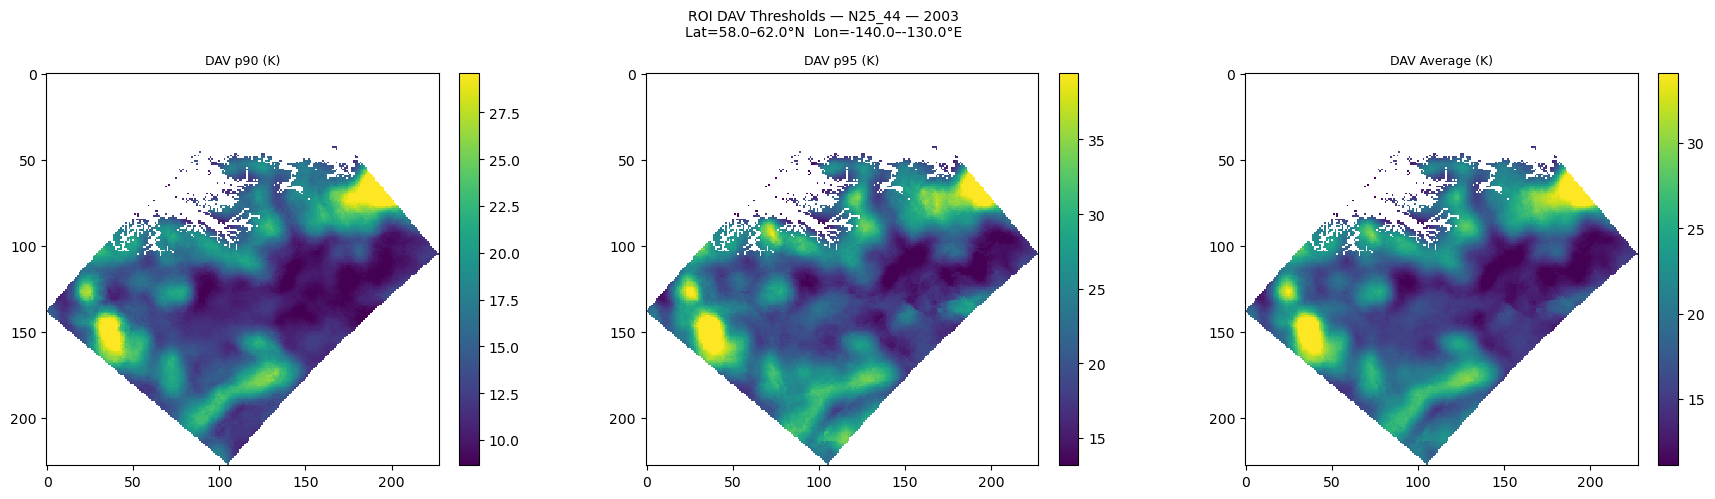

 Preview saved: DAVThresholds_2003_SSMI_Cube44_N25_44_ROI_lat58.0-62.0_lon-140.0--130.0_preview.png

 Open the GeoTIFF in QGIS or ArcGIS Pro.


In [20]:
print(f"Converting ROI CSV to GeoTIFF...")
print(f"   Source: {os.path.basename(csv_roi)}")

df_roi   = pd.read_csv(csv_roi)
x_offset = int(df_roi["x"].min())
y_offset = int(df_roi["y"].min())
nx_roi   = int(df_roi["x"].max()) - x_offset + 1
ny_roi   = int(df_roi["y"].max()) - y_offset + 1

print(f"   Grid size : {nx_roi} cols x {ny_roi} rows")

# Build transform from anchor pixel
y_min_val  = int(df_roi["y"].min())
anchor_row = df_roi[df_roi["y"] == y_min_val].sort_values("x").iloc[0]
x_m_roi, y_m_roi = to_ease.transform(
    float(anchor_row["Longitude"]), float(anchor_row["Latitude"])
)
west_roi  = x_m_roi - 3125.0 / 2
south_roi = y_m_roi + 3125.0 / 2
transform_roi = Affine(3125.0, 0.0, west_roi, 0.0, -3125.0, south_roi)

# Fill grids
grid_p90 = np.full((ny_roi, nx_roi), -9999.0, dtype=np.float32)
grid_p95 = np.full((ny_roi, nx_roi), -9999.0, dtype=np.float32)
grid_avg = np.full((ny_roi, nx_roi), -9999.0, dtype=np.float32)

xi_roi   = df_roi["x"].values.astype(int) - x_offset
yi_roi   = df_roi["y"].values.astype(int) - y_offset
p90_vals = pd.to_numeric(df_roi["DAV_Threshold_90_Percentile"], errors="coerce").values.astype(float)
p95_vals = pd.to_numeric(df_roi["DAV_Threshold_95_Percentile"], errors="coerce").values.astype(float)
avg_vals = pd.to_numeric(df_roi["DAV_Threshold_Average"],       errors="coerce").values.astype(float)

grid_p90[yi_roi[~np.isnan(p90_vals)], xi_roi[~np.isnan(p90_vals)]] = p90_vals[~np.isnan(p90_vals)]
grid_p95[yi_roi[~np.isnan(p95_vals)], xi_roi[~np.isnan(p95_vals)]] = p95_vals[~np.isnan(p95_vals)]
grid_avg[yi_roi[~np.isnan(avg_vals)], xi_roi[~np.isnan(avg_vals)]] = avg_vals[~np.isnan(avg_vals)]

tif_roi = csv_roi.replace(".csv", ".tif")
with rasterio.open(
    tif_roi, "w",
    driver="GTiff", height=ny_roi, width=nx_roi, count=3,
    dtype=np.float32, crs=rasterio.CRS.from_epsg(6931),
    transform=transform_roi, nodata=-9999.0,
    compress="deflate", tiled=True, blockxsize=256, blockysize=256,
) as dst:
    dst.write(grid_p90, 1)
    dst.write(grid_p95, 2)
    dst.write(grid_avg, 3)
    dst.update_tags(
        BAND_1="DAV_Threshold_90_Percentile",
        BAND_2="DAV_Threshold_95_Percentile",
        BAND_3="DAV_Threshold_Average",
    )

print(f"\n ROI GeoTIFF saved: {tif_roi}")
print(f"   Size     : {nx_roi} x {ny_roi} pixels")
print(f"   CRS      : EPSG:6931 (EASE-Grid 2.0 North)")
print(f"   Location : Lat={ROI_lat_min}–{ROI_lat_max}°N  Lon={ROI_lon_min}–{ROI_lon_max}°E")

# --- Quick preview plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    f"ROI DAV Thresholds — {region} — {years_tag}\n"
    f"Lat={ROI_lat_min}–{ROI_lat_max}°N  Lon={ROI_lon_min}–{ROI_lon_max}°E",
    fontsize=10
)
band_names = ["DAV p90 (K)", "DAV p95 (K)", "DAV Average (K)"]
grids      = [grid_p90, grid_p95, grid_avg]

for ax, grid, name in zip(axes, grids, band_names):
    arr = grid.astype(float)
    arr[arr == -9999.0] = np.nan
    valid = arr[~np.isnan(arr)]
    if len(valid) == 0:
        ax.set_title(f"{name}\n(no valid data)")
        ax.axis("off")
        continue
    vmin = np.percentile(valid, 2)
    vmax = np.percentile(valid, 98)
    im = ax.imshow(arr, cmap="viridis", vmin=vmin, vmax=vmax,
                   interpolation="none", origin="lower")
    ax.invert_yaxis()
    ax.set_title(name, fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
preview_roi = tif_roi.replace(".tif", "_preview.png")
plt.savefig(preview_roi, dpi=150, bbox_inches="tight")
plt.show()
print(f" Preview saved: {os.path.basename(preview_roi)}")
print(f"\n Open the GeoTIFF in QGIS or ArcGIS Pro.")

## 5.  Save Single-Pixel Results to CSV

Save the single-pixel results from Sections 4A and 4B to CSV files.

In [21]:
# 'single' = Section 4A only | 'cumulative' = Section 4B only | 'both' = save both
SAVE_MODE = "both"   # change if needed

header   = ["Site", "Snow Class", "Latitude", "Longitude",
             "x", "y",
             "DAV_Threshold_90_Percentile",
             "DAV_Threshold_95_Percentile",
             "DAV_Threshold_Average"]

row_data = [
    f"{pixel_row},{pixel_col}",
    snow_class,
    pixel_lat,
    pixel_lon,
    pixel_col,
    pixel_row,
]

if SAVE_MODE in ("single", "both"):
    csv_single = os.path.join(
        OutDir,
        f"DAVThresholds_{year_single}_{sensor_SIR}_{SiteLabel}_{region}_lat{pixel_lat:.2f}_lon{pixel_lon:.2f}.csv"
    )
    with open(csv_single, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(header)
        w.writerow(row_data + [p90_single, p95_single, avg_single])
    print(f" Single-year CSV saved:\n   {csv_single}")

if SAVE_MODE in ("cumulative", "both"):
    csv_cumul = os.path.join(
        OutDir,
        f"DAVThresholds_{year_list[0]}-{year_list[-1]}_{sensor_SIR}_{SiteLabel}_{region}_"
        f"DOY{MELT_DOY_START}-{MELT_DOY_END}_lat{pixel_lat:.2f}_lon{pixel_lon:.2f}.csv"
    )
    with open(csv_cumul, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(header)
        w.writerow(row_data + [p90_all, p95_all, avg_all])
    print(f" Cumulative CSV saved:\n   {csv_cumul}")

print("\n Summary of saved values:")
print(f"   Location : Lat={pixel_lat:.4f}°N  Lon={pixel_lon:.4f}°E")
print(f"   Snow class: {snow_class}")
if SAVE_MODE in ("single", "both"):
    print(f"   [{year_single}]     p90={p90_single}  p95={p95_single}  avg={avg_single}")
if SAVE_MODE in ("cumulative", "both"):
    print(f"   [All years]  p90={p90_all}  p95={p95_all}  avg={avg_all}")

 Single-year CSV saved:
   /scratch/alpine/mabo7890/DAV_Thresholds/Interactive/DAVThresholds_2003_SSMI_Cube44_N25_44_lat60.51_lon-135.00.csv
 Cumulative CSV saved:
   /scratch/alpine/mabo7890/DAV_Thresholds/Interactive/DAVThresholds_1995-2009_SSMI_Cube44_N25_44_DOY60-180_lat60.51_lon-135.00.csv

 Summary of saved values:
   Location : Lat=60.5100°N  Lon=-135.0000°E
   Snow class: Boreal Forest
   [2003]     p90=9.366006469726559  p95=13.52951126098632  avg=11.44775886535644
   [All years]  p90=18.638006591796877  p95=22.78399963378906  avg=20.711003112792966


## 6. Single-Pixel Results Summary

In [22]:
print("\n Single-pixel results summary:")
print(f"   Lat={pixel_lat:.4f}°N  Lon={pixel_lon:.4f}°E")
print(f"   Snow class : {snow_class}")
print(f"   DAV p90    : {p90_all:.2f} K")
print(f"   DAV p95    : {p95_all:.2f} K")
print(f"   DAV Average: {avg_all:.2f} K")
print(f"\n   For spatial output use Section 4C/4D (ROI analysis).")


 Single-pixel results summary:
   Lat=60.5100°N  Lon=-135.0000°E
   Snow class : Boreal Forest
   DAV p90    : 18.64 K
   DAV p95    : 22.78 K
   DAV Average: 20.71 K

   For spatial output use Section 4C/4D (ROI analysis).
